                               mean  median       std  min  max  count
Dimension           Method                                            
coherence_score     Baseline  7.200     8.0  1.651728    3   10     40
                    Harpa     7.075     8.0  1.654636    1   10     40
confidence_score    Baseline  4.325     4.0  0.655842    3    5     40
                    Harpa     4.375     4.0  0.667467    3    5     40
effectiveness_score Baseline  6.775     7.0  1.656185    3   10     40
                    Harpa     6.650     7.0  1.687815    1    9     40
excitement_score    Baseline  6.450     7.0  1.535060    3    8     40
                    Harpa     6.250     6.0  1.480644    3    8     40
familiarity_score   Baseline  3.925     4.0  0.944281    2    5     40
                    Harpa     4.050     4.0  0.932325    2    5     40
feasibility_score   Baseline  5.500     5.0  1.724633    3    9     40
                    Harpa     6.275     6.0  2.075344    1   10     40
ground

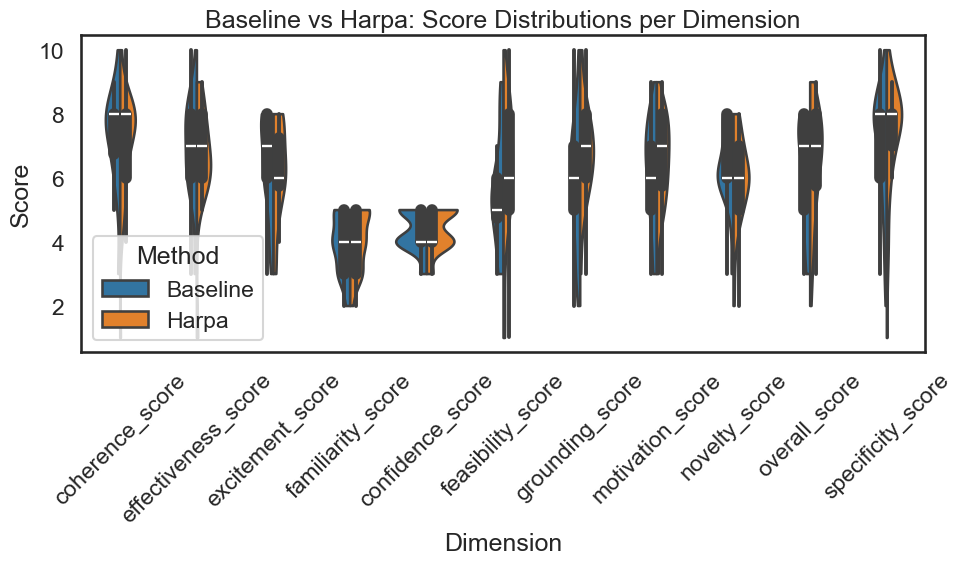

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Read your CSVs ===
df_baseline = pd.read_csv("baseline_final.csv")
df_harpa = pd.read_csv("harpa_final.csv")

# Add labels
df_baseline["Method"] = "Baseline"
df_harpa["Method"] = "Harpa"

# Combine into one dataframe
df = pd.concat([df_baseline, df_harpa], ignore_index=True)

# Reshape from wide → long
df_long = df.melt(id_vars="Method", 
                  var_name="Dimension", 
                  value_name="Score")

# === Summary stats ===
summary = df_long.groupby(["Dimension","Method"])["Score"].agg(
    ["mean","median","std","min","max","count"]
)
print(summary)

# === Violin plots ===
plt.figure(figsize=(10,6))
sns.violinplot(x="Dimension", y="Score", hue="Method", data=df_long,
               split=True, inner="box", cut=0)

plt.title("Baseline vs Harpa: Score Distributions per Dimension")
plt.ylabel("Score")
plt.xlabel("Dimension")
plt.xticks(rotation=45)
plt.legend(title="Method")
plt.tight_layout()
plt.show()


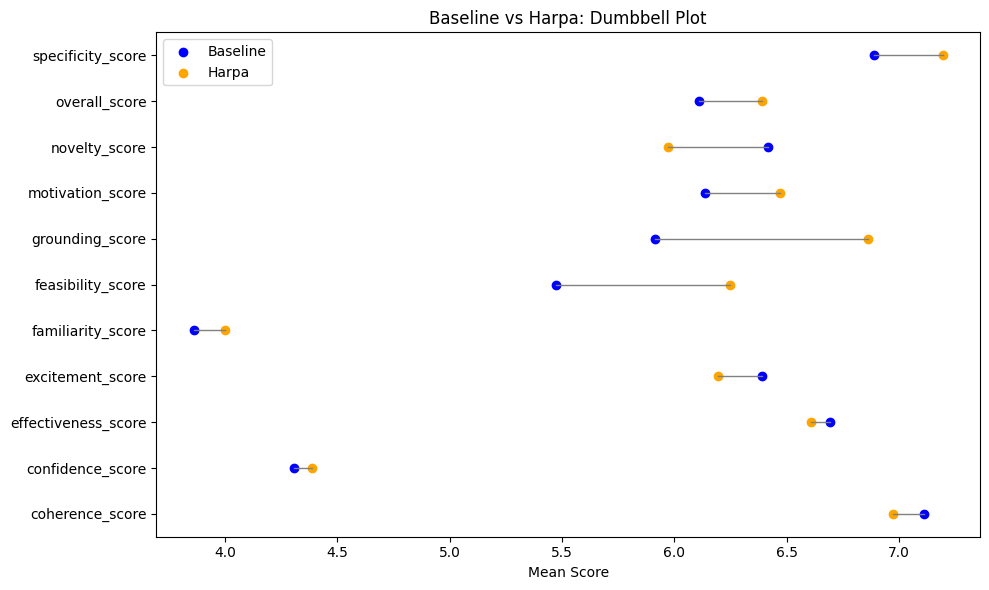

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# === Your combined long dataframe ===
# df_long has: Method | Dimension | Score

# --- Compute means per Method × Dimension ---
summary = df_long.groupby(["Dimension", "Method"])["Score"].mean().reset_index()

# Pivot so we get Baseline and Harpa side by side
summary_pivot = summary.pivot(index="Dimension", columns="Method", values="Score").reset_index()

# --- Dumbbell plot ---
plt.figure(figsize=(10,6))
for i, row in summary_pivot.iterrows():
    plt.plot([row["Baseline"], row["Harpa"]], [i, i], color="gray", lw=1)  # line
    plt.scatter(row["Baseline"], i, color="blue", label="Baseline" if i==0 else "")
    plt.scatter(row["Harpa"], i, color="orange", label="Harpa" if i==0 else "")

plt.yticks(range(len(summary_pivot)), summary_pivot["Dimension"])
plt.xlabel("Mean Score")
plt.title("Baseline vs Harpa: Dumbbell Plot")
plt.legend()
plt.tight_layout()
plt.show()


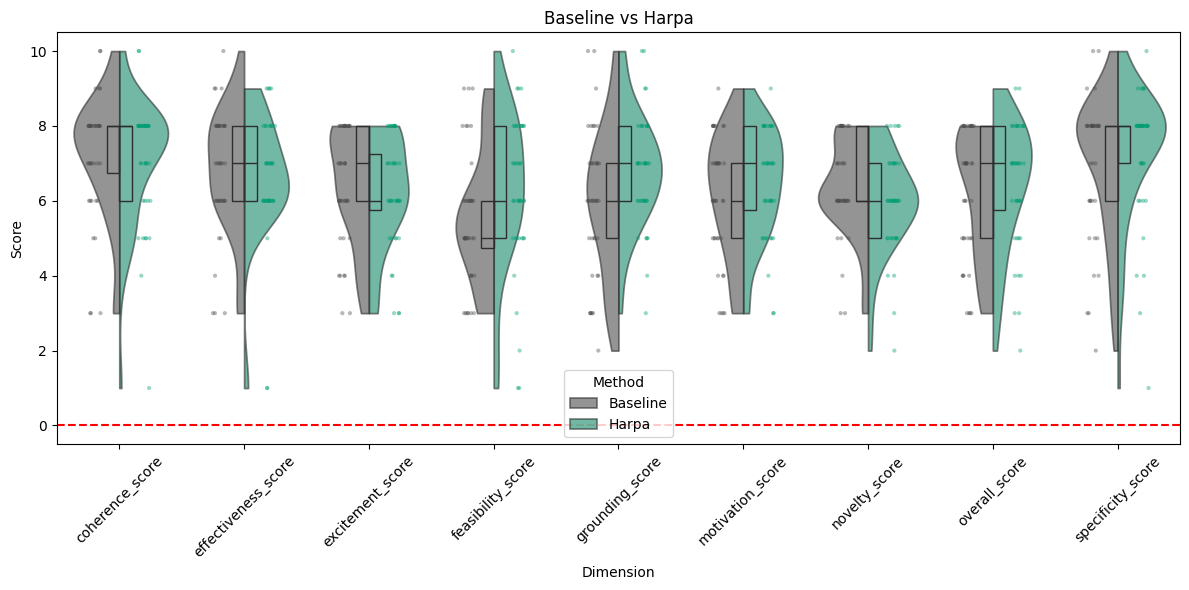

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df_long already exists: Method | Dimension | Score
# Remove unwanted dimensions
df_long_filtered = df_long[~df_long["Dimension"].isin(["familiarity_score", "confidence_score"])]
palette = {"Baseline": "#4D4D4D", "Harpa": "#009E73"}

plt.figure(figsize=(12,6))

sns.violinplot(x="Dimension", y="Score", hue="Method",
               data=df_long_filtered, split=True, inner=None, cut=0, alpha=0.6,
               palette=palette)

sns.boxplot(x="Dimension", y="Score", hue="Method",
            data=df_long_filtered, showcaps=False, boxprops={'facecolor':'None'},
            showfliers=False, whiskerprops={'linewidth':0}, width=0.2,
               palette=palette)

sns.stripplot(x="Dimension", y="Score", hue="Method",
              data=df_long_filtered, dodge=True, alpha=0.4, size=3, jitter=True,
               palette=palette)

plt.axhline(0, color="red", linestyle="--")   # optional reference line
plt.xticks(rotation=45)
plt.title("Baseline vs Harpa")
plt.ylabel("Score")
plt.xlabel("Dimension")
plt.tight_layout()

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title="Method")
plt.savefig("baseline_vs_harpa.pdf", format="pdf")

plt.show()



In [20]:
import pandas as pd
from statsmodels.multivariate.manova import MANOVA
from scipy.stats import ttest_1samp, wilcoxon
import numpy as np

df = pd.read_csv("diff_scores_final.csv")

# --- MANOVA across all dimensions ---
formula = " + ".join(df.columns) + " ~ 1"
maov = MANOVA.from_formula(formula, data=df)
print(maov.mv_test())

# --- Follow-up univariate tests for each dimension ---
print("\nFollow-up univariate tests:")
for col in df.columns:
    scores = df[col].dropna()

    mean_diff = np.mean(scores)
    t_stat, t_p = ttest_1samp(scores, 0)
    try:
        w_stat, w_p = wilcoxon(scores)
    except ValueError:
        w_p = np.nan

    print(f"{col:20s} mean={mean_diff:6.3f}  t_p={t_p:.3f}  wilcoxon_p={w_p:.3f}")


                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value   Num DF  Den DF F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.5567 11.0000 29.0000  2.0995 0.0541
         Pillai's trace 0.4433 11.0000 29.0000  2.0995 0.0541
 Hotelling-Lawley trace 0.7963 11.0000 29.0000  2.0995 0.0541
    Roy's greatest root 0.7963 11.0000 29.0000  2.0995 0.0541


Follow-up univariate tests:
coherence_score      mean=-0.125  t_p=0.695  wilcoxon_p=0.806
effectiveness_score  mean=-0.125  t_p=0.704  wilcoxon_p=0.716
excitement_score     mean=-0.200  t_p=0.544  wilcoxon_p=0.435
familiarity_score    mean= 0.125  t_p=0.376  wilcoxon_p=0.394
confidence_score     mean= 0.050  t_p=0.660  wilcoxon_p=0.660
feasibility_score    mean= 0.775  t_p=0.038  wilcoxon_p=0.016
grounding_score      mean= 0.850  t_p=0.012  wilcoxon_p=0.

/var/folders/30/nb0zdrdn59g2mzr_dg865x840000gn/T/ipykernel_56124/312127409.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=res_df, x="MeanDiff", y="Dimension", join=False, color="black")


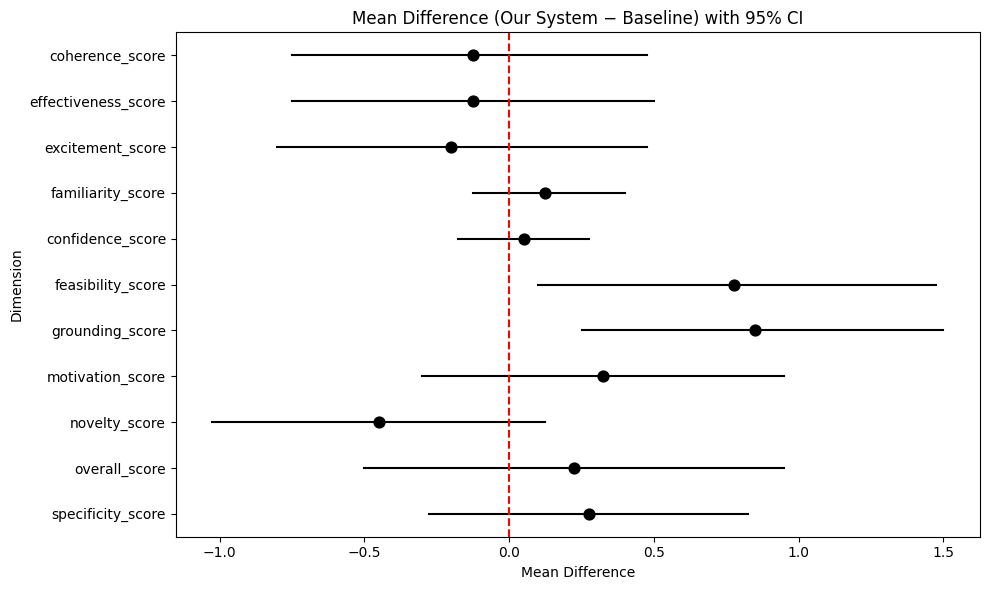

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Load your per-example diffs (system - baseline) per dimension
df = pd.read_csv("diff_scores_final.csv")

def bootstrap_ci(data, num_samples=5000, ci=95):
    """Bootstrap confidence interval for the mean"""
    means = []
    n = len(data)
    for _ in range(num_samples):
        resample = [random.choice(data) for _ in range(n)]
        means.append(np.mean(resample))
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return lower, upper

# Collect mean + CI for each dimension
results = []
for col in df.columns:
    scores = df[col].dropna().tolist()
    mean_diff = np.mean(scores)
    ci_low, ci_high = bootstrap_ci(scores)
    results.append((col, mean_diff, ci_low, ci_high))

res_df = pd.DataFrame(results, columns=["Dimension", "MeanDiff", "CI_low", "CI_high"])

# Plot
plt.figure(figsize=(10,6))
sns.pointplot(data=res_df, x="MeanDiff", y="Dimension", join=False, color="black")
for i, row in res_df.iterrows():
    plt.plot([row["CI_low"], row["CI_high"]], [i, i], color="black")  # CI line

plt.axvline(0, color="red", linestyle="--")  # baseline reference
plt.title("Mean Difference (Our System − Baseline) with 95% CI")
plt.xlabel("Mean Difference")
plt.ylabel("Dimension")
plt.tight_layout()
plt.show()


/var/folders/30/nb0zdrdn59g2mzr_dg865x840000gn/T/ipykernel_56124/2553186845.py:75: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(ax=axes[1], data=res_df, x="MeanDiff", y="Dimension", join=False, color="black")


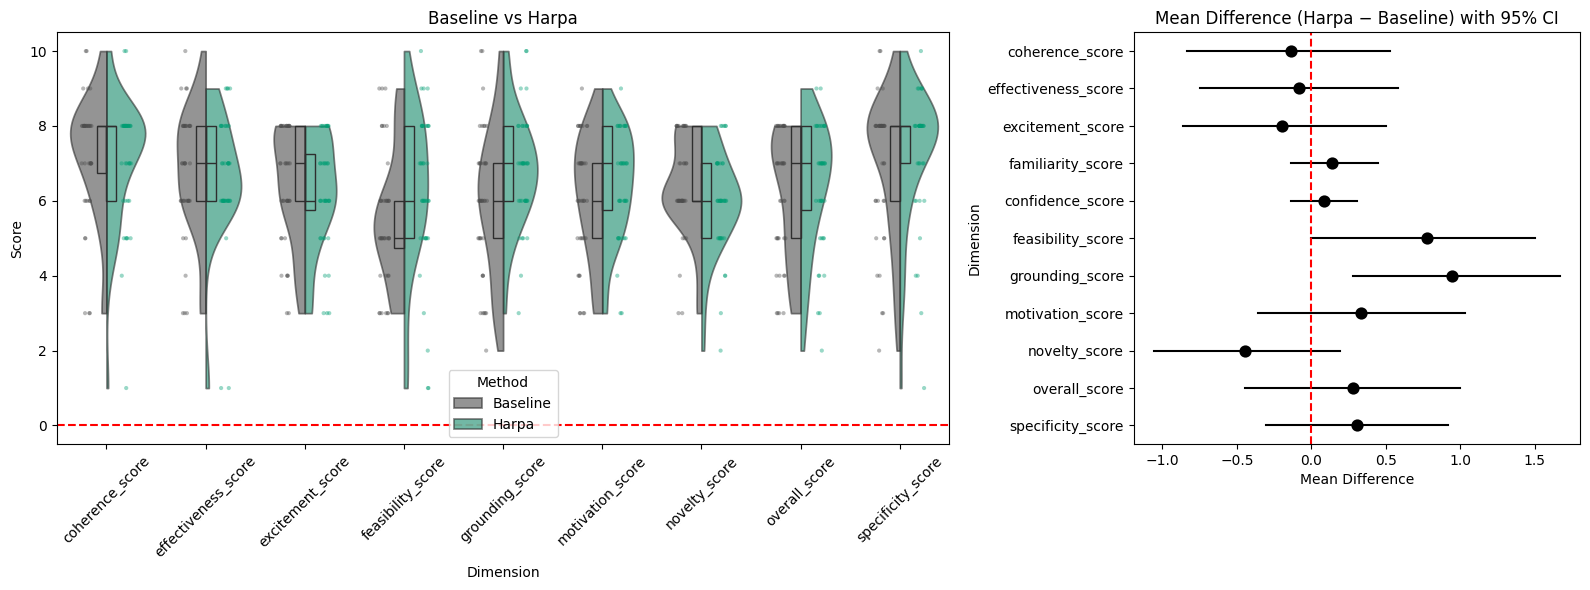

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ==============================
# Part 1: Data Loading
# ==============================
df_baseline = pd.read_csv("baseline_final.csv")
df_harpa = pd.read_csv("harpa_final.csv")
df_baseline["Method"] = "Baseline"
df_harpa["Method"] = "Harpa"
df = pd.concat([df_baseline, df_harpa], ignore_index=True)

# Wide → long for violin plot
df_long = df.melt(id_vars="Method", var_name="Dimension", value_name="Score")
df_long_filtered = df_long[~df_long["Dimension"].isin(["familiarity_score", "confidence_score"])]

# Load per-example diffs (system - baseline) for CI plot
df_diff = pd.read_csv("diff_scores.csv")

# ==============================
# Part 2: Bootstrap CI
# ==============================
def bootstrap_ci(data, num_samples=5000, ci=95):
    """Bootstrap confidence interval for the mean"""
    means = []
    n = len(data)
    for _ in range(num_samples):
        resample = [random.choice(data) for _ in range(n)]
        means.append(np.mean(resample))
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return lower, upper

results = []
for col in df_diff.columns:
    scores = df_diff[col].dropna().tolist()
    mean_diff = np.mean(scores)
    ci_low, ci_high = bootstrap_ci(scores)
    results.append((col, mean_diff, ci_low, ci_high))

res_df = pd.DataFrame(results, columns=["Dimension", "MeanDiff", "CI_low", "CI_high"])

# ==============================
# Part 3: Combined Plot
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios':[2,1]})

# --- Left: Violin Plot ---
palette = {"Baseline": "#4D4D4D", "Harpa": "#009E73"}
sns.violinplot(ax=axes[0], x="Dimension", y="Score", hue="Method",
               data=df_long_filtered, split=True, inner=None, cut=0, alpha=0.6,
               palette=palette)
sns.boxplot(ax=axes[0], x="Dimension", y="Score", hue="Method",
            data=df_long_filtered, showcaps=False, boxprops={'facecolor':'None'},
            showfliers=False, whiskerprops={'linewidth':0}, width=0.2,
            palette=palette)
sns.stripplot(ax=axes[0], x="Dimension", y="Score", hue="Method",
              data=df_long_filtered, dodge=True, alpha=0.4, size=3, jitter=True,
              palette=palette)

axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Baseline vs Harpa")
axes[0].set_ylabel("Score")
axes[0].set_xlabel("Dimension")
axes[0].tick_params(axis='x', rotation=45)

# Fix duplicate legends
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], labels[:2], title="Method")

# --- Right: Mean Differences Plot ---
sns.pointplot(ax=axes[1], data=res_df, x="MeanDiff", y="Dimension", join=False, color="black")
for i, row in res_df.iterrows():
    axes[1].plot([row["CI_low"], row["CI_high"]], [i, i], color="black")  # CI lines

axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Mean Difference (Harpa − Baseline) with 95% CI")
axes[1].set_xlabel("Mean Difference")
axes[1].set_ylabel("Dimension")

plt.tight_layout()
plt.savefig("combined_violin_diff.pdf", format="pdf")
plt.show()


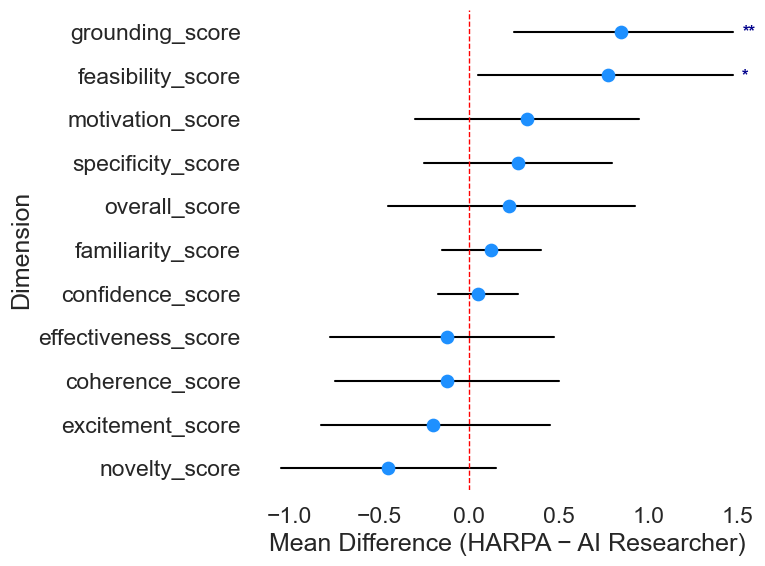

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ---------- Utility functions ----------
def bootstrap_ci(data, num_samples=5000, ci=95):
    means = []
    n = len(data)
    for _ in range(num_samples):
        resample = [random.choice(data) for _ in range(n)]
        means.append(np.mean(resample))
    lower = np.percentile(means, (100-ci)/2)
    upper = np.percentile(means, 100-(100-ci)/2)
    return lower, upper

def bootstrap_resample(diff_scores:list, num_samples=10000, threshold=0):
    num_above_threshold = 0
    for _ in range(num_samples):
        resample = [random.choice(diff_scores) for _ in range(len(diff_scores))]
        mean_resample = sum(resample) / len(resample)
        if mean_resample > threshold:
            num_above_threshold += 1
    return 1 - (num_above_threshold / num_samples)

def stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

# ---------- Load and compute ----------
df = pd.read_csv("diff_scores_final.csv")
results = []
for col in df.columns:
    scores = df[col].dropna().tolist()
    if len(scores) == 0:
        continue
    mean_diff = np.mean(scores)
    ci_low, ci_high = bootstrap_ci(scores)
    boot_p = bootstrap_resample(scores)
    results.append((col, mean_diff, ci_low, ci_high, boot_p, stars(boot_p)))

res_df = pd.DataFrame(results, columns=["Dimension", "MeanDiff", "CI_low", "CI_high", "p_boot", "stars"])
res_df = res_df.sort_values("MeanDiff", ascending=True).reset_index(drop=True)

# ---------- Plot ----------
plt.figure(figsize=(8,6))
sns.set_style("white")  # no grid
sns.set_context("talk")

# Plot points + CI bars manually for more control
for i, row in res_df.iterrows():
    plt.plot([row["CI_low"], row["CI_high"]], [i, i], color="black", lw=1.5)   # CI line
    plt.scatter(row["MeanDiff"], i, s=70, color="dodgerblue", zorder=3)        # point
    plt.text(row["CI_high"] + 0.05, i, row["stars"], va="center",
             fontsize=12, fontweight="bold", color="darkblue")

# Reference line at 0
plt.axvline(0, color="red", linestyle="--", lw=1)

# Axes formatting
plt.yticks(range(len(res_df)), res_df["Dimension"])
plt.xlabel("Mean Difference (HARPA − AI Researcher)")
plt.ylabel("Dimension")
sns.despine(left=True, bottom=True)  # clean look


# ---------- Save as PDF ----------
plt.tight_layout()
plt.savefig("mean_diff_ci_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()
